# 04 - Results Analysis: Experiment A/B/C Comparison

Loads `results/metrics/experiment_comparison.json` (produced by `scripts/run_experiment.py`) and visualizes how each pipeline stage changes roof-area / usable-area / panel-count / capacity error relative to the ground-truth oracle reference. If the file does not exist yet, run:

```
python scripts/run_experiment.py --config configs/unet.yaml
```

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

report_path = Path('../results/metrics/experiment_comparison.json')
if report_path.exists():
    report = json.loads(report_path.read_text())
    print(f"Test samples: {report['num_test_samples']}")
    print('\nSegmentation metrics (roof segments):')
    print(json.dumps(report['segmentation_metrics_roof_segments'], indent=2))
    print('\nSegmentation metrics (superstructures):')
    print(report['segmentation_metrics_superstructures'] if isinstance(report['segmentation_metrics_superstructures'], str) else json.dumps(report['segmentation_metrics_superstructures'], indent=2))
else:
    report = None
    print('experiment_comparison.json not found yet -- run scripts/run_experiment.py first.')

Test samples: 18

Segmentation metrics (roof segments):
{
  "mean_iou": 0.12807986822280398,
  "mean_dice": 0.1501398847197898,
  "mean_precision": 0.2216694093741626,
  "mean_recall": 0.2006358949843529,
  "pixel_accuracy": 0.8193427191840278
}

Segmentation metrics (superstructures):
{
  "mean_iou": 0.7298783309905268,
  "mean_dice": 0.7396279097565429,
  "mean_precision": 0.9819962031020141,
  "mean_recall": 0.742957052166284,
  "pixel_accuracy": 0.9965252346462674
}


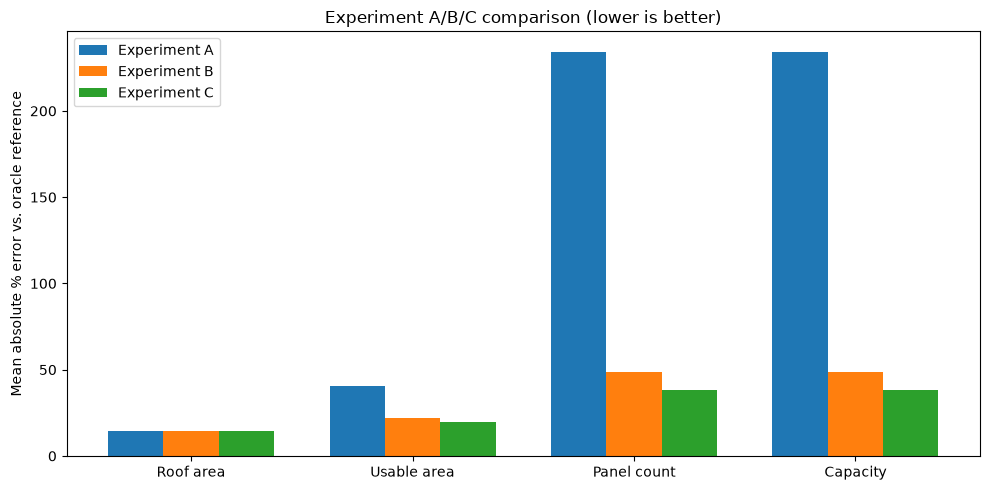


Experiment A: 2D roof segmentation only (naive area/panel_area panel count, no geometric reasoning)
  roof_area_m2: 14.5% mean abs error vs reference
  usable_area_m2: 40.7% mean abs error vs reference
  num_panels: 234.4% mean abs error vs reference
  capacity_kwp: 234.4% mean abs error vs reference

Experiment B: Roof segmentation + geometric reasoning (real placement, edge margin, no obstacle removal)
  roof_area_m2: 14.5% mean abs error vs reference
  usable_area_m2: 22.0% mean abs error vs reference
  num_panels: 48.4% mean abs error vs reference
  capacity_kwp: 48.4% mean abs error vs reference

Experiment C: Roof segmentation + geometric reasoning + obstacle detection (full pipeline)
  roof_area_m2: 14.5% mean abs error vs reference
  usable_area_m2: 19.8% mean abs error vs reference
  num_panels: 38.1% mean abs error vs reference
  capacity_kwp: 38.1% mean abs error vs reference


In [2]:
if report is not None:
    summary = report['mean_absolute_pct_error_vs_reference']
    metrics = ['roof_area_m2', 'usable_area_m2', 'num_panels', 'capacity_kwp']
    experiments = ['A', 'B', 'C']
    x = np.arange(len(metrics))
    width = 0.25
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, exp in enumerate(experiments):
        values = [summary[exp][m]['mean_absolute_pct_error'] for m in metrics]
        ax.bar(x + i * width, values, width, label=f'Experiment {exp}')
    ax.set_xticks(x + width)
    ax.set_xticklabels(['Roof area', 'Usable area', 'Panel count', 'Capacity'])
    ax.set_ylabel('Mean absolute % error vs. oracle reference')
    ax.set_title('Experiment A/B/C comparison (lower is better)')
    ax.legend()
    fig.tight_layout()
    plt.show()
    for exp in experiments:
        print(f"\nExperiment {exp}: {report['experiment_descriptions'][exp]}")
        for m in metrics:
            print(f"  {m}: {summary[exp][m]['mean_absolute_pct_error']:.1f}% mean abs error vs reference")

## Discussion

See `docs/research_report.md` §7-§9 for the full discussion of these results, and §10 for the limitations that apply to any numbers shown above (CPU-only training budget, synthetic-data substrate in place of licensed real RID raster data).